# Results and Data Analysis for Movie Recommender

This notebook provides visualizations for the Project Report's **Results and Discussion** section. 
It includes exploratory data analysis (EDA) of the input datasets and graphs depicting the evaluation metrics of our recommendation system.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
from data_loader import load_movies, load_ratings
from evaluation import compute_metrics

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Dataset Overview

In [2]:
# Load data using the backend's data_loader
movies_df = load_movies()
ratings_df = load_ratings()

print(f"Total Movies: {len(movies_df):,}")
print(f"Total Ratings: {len(ratings_df):,}")

Total Movies: 10,329
Total Ratings: 105,339


## 2. Distribution of Ratings
Visualizing how users rate movies. Are people generally generous or strict with their ratings?

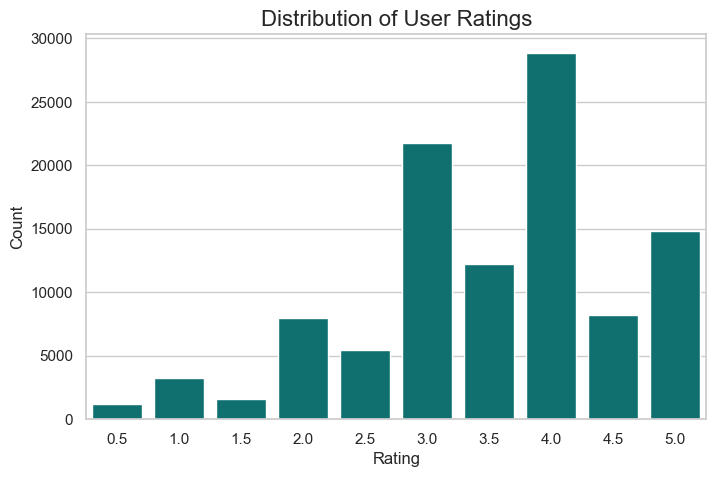

In [3]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='rating', data=ratings_df, color='teal')
plt.title('Distribution of User Ratings', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()
ax.figure.savefig("rating_distribution.png", dpi=300)

## 3. Top Genres in the Dataset

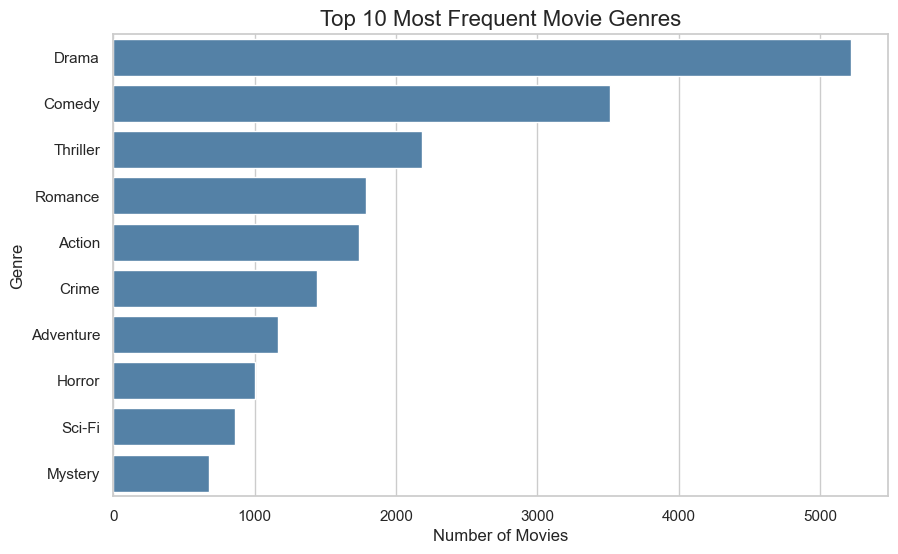

In [4]:
# Split the genres string into individual genres, then explode into separate rows
genres_exploded = movies_df['genres'].str.split('|').explode()
genre_counts = genres_exploded.value_counts().head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=genre_counts.values, y=genre_counts.index, color='steelblue')
plt.title('Top 10 Most Frequent Movie Genres', fontsize=16)
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.show()
ax.figure.savefig("top_genres.png", dpi=300)

## 4. Deeper EDA: User Behavior and Catalog Popularity
To strengthen the final report narrative, this section studies user activity levels and movie popularity distribution. These patterns explain sparse feedback and long-tail behavior in recommendation tasks.

User activity summary:
count     668.00
mean      157.69
std       319.71
min        20.00
25%        35.00
50%        70.50
75%       153.00
max      5678.00
dtype: float64


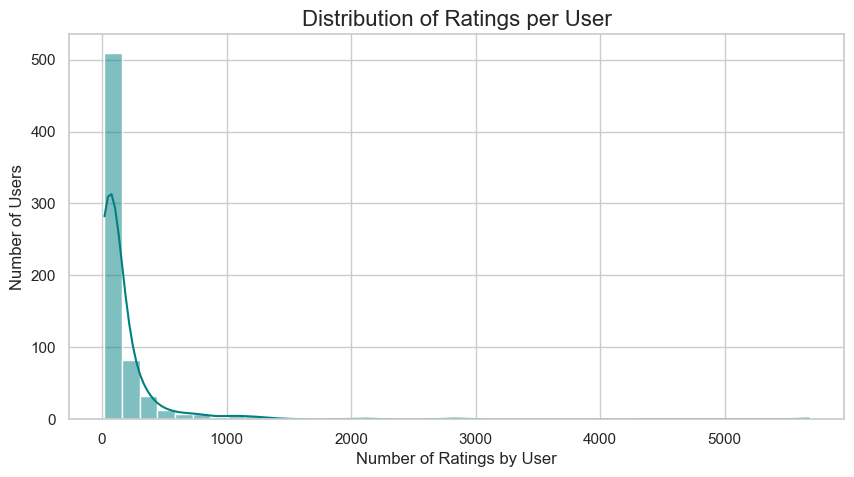

In [5]:
# Ratings per user: activity distribution
ratings_per_user = ratings_df.groupby('userId').size()

print('User activity summary:')
print(ratings_per_user.describe().round(2))

plt.figure(figsize=(10, 5))
ax = sns.histplot(ratings_per_user, bins=40, kde=True, color='teal')
plt.title('Distribution of Ratings per User', fontsize=16)
plt.xlabel('Number of Ratings by User', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.show()
ax.figure.savefig('ratings_per_user_distribution.png', dpi=300)

Interpretation: The histogram shows a right-skewed user activity pattern. Most users contribute only a small number of ratings, while a smaller group is highly active. This sparsity motivates hybrid recommendation strategies because user profiles are uneven in depth.

Movie popularity summary:
count    10325.00
mean        10.20
std         22.83
min          1.00
25%          1.00
50%          3.00
75%          8.00
max        325.00
dtype: float64


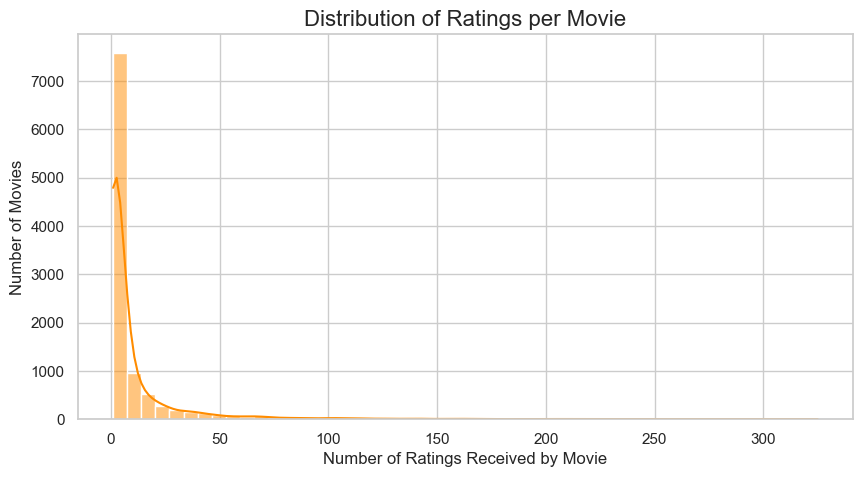

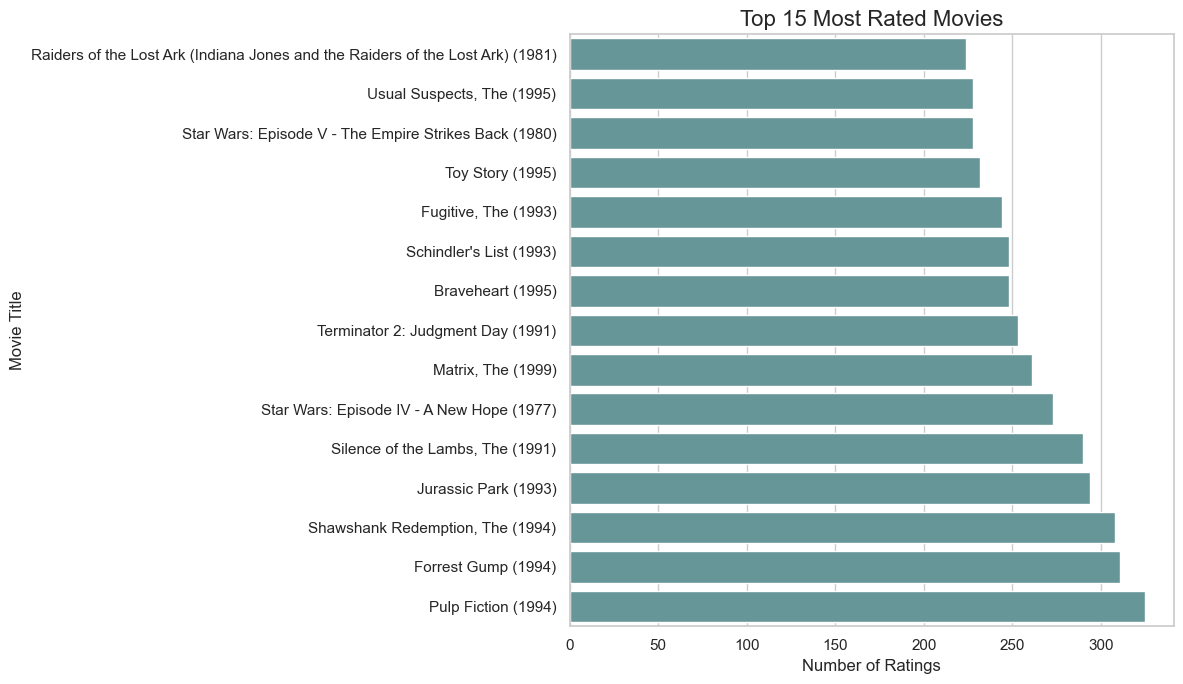

In [6]:
# Ratings per movie: popularity long-tail
ratings_per_movie = ratings_df.groupby('movieId').size().sort_values(ascending=False)

print('Movie popularity summary:')
print(ratings_per_movie.describe().round(2))

plt.figure(figsize=(10, 5))
ax = sns.histplot(ratings_per_movie, bins=50, kde=True, color='darkorange')
plt.title('Distribution of Ratings per Movie', fontsize=16)
plt.xlabel('Number of Ratings Received by Movie', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.show()
ax.figure.savefig('ratings_per_movie_distribution.png', dpi=300)

# Top most-rated movies for interpretability
popular_movie_ids = ratings_per_movie.head(15).index
popular_movies = movies_df[movies_df['movieId'].isin(popular_movie_ids)].copy()
popular_movies['rating_count'] = popular_movies['movieId'].map(ratings_per_movie)
popular_movies = popular_movies.sort_values('rating_count', ascending=True)

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=popular_movies, x='rating_count', y='title', color='cadetblue')
plt.title('Top 15 Most Rated Movies', fontsize=16)
plt.xlabel('Number of Ratings', fontsize=12)
plt.ylabel('Movie Title', fontsize=12)
plt.tight_layout()
plt.show()
ax.figure.savefig('top_rated_movies_count.png', dpi=300)

Interpretation: Movie popularity follows a long-tail structure. A limited set of titles receives many interactions, while most movies receive relatively few ratings. The top-15 chart highlights head items that dominate engagement and can bias naive recommenders toward already-popular content.

## 5. Feature Engineering for Richer Insights
In this section, we create additional columns to enrich analysis: release year, decade, average movie rating, rating count, and a weighted score that balances quality and popularity.

In [7]:
# Build enriched movie table with additional analytical columns
movies_enriched = movies_df.copy()

# Extract year from title format like "Movie Name (1995)"
movies_enriched['release_year'] = pd.to_numeric(
    movies_enriched['title'].str.extract(r'\((\d{4})\)')[0],
    errors='coerce'
)
movies_enriched['decade'] = (movies_enriched['release_year'] // 10 * 10).astype('Int64')

movie_stats = (
    ratings_df.groupby('movieId')['rating']
    .agg(avg_rating='mean', rating_count='count')
    .reset_index()
)

movies_enriched = movies_enriched.merge(movie_stats, on='movieId', how='left')

# Weighted score: shrinks low-count movies toward global mean
C = ratings_df['rating'].mean()
m = movies_enriched['rating_count'].quantile(0.75)
movies_enriched['weighted_score'] = (
    (movies_enriched['rating_count'] / (movies_enriched['rating_count'] + m)) * movies_enriched['avg_rating']
    + (m / (movies_enriched['rating_count'] + m)) * C
)

print('New columns added: release_year, decade, avg_rating, rating_count, weighted_score')
print(movies_enriched[['title', 'release_year', 'decade', 'avg_rating', 'rating_count', 'weighted_score']].head())

New columns added: release_year, decade, avg_rating, rating_count, weighted_score
                                title  release_year  decade  avg_rating  \
0                    Toy Story (1995)        1995.0    1990    3.907328   
1                      Jumanji (1995)        1995.0    1990    3.353261   
2             Grumpier Old Men (1995)        1995.0    1990    3.189655   
3            Waiting to Exhale (1995)        1995.0    1990    2.818182   
4  Father of the Bride Part II (1995)        1995.0    1990    3.250000   

   rating_count  weighted_score  
0         232.0        3.894312  
1          92.0        3.366348  
2          58.0        3.229315  
3          11.0        3.112358  
4          62.0        3.280497  


Interpretation: The scatter plot suggests that higher engagement does not automatically imply higher quality, although very low-support items are more volatile. The log-scaled x-axis makes the tail visible and shows why confidence-aware ranking (for example, weighted score) is useful.

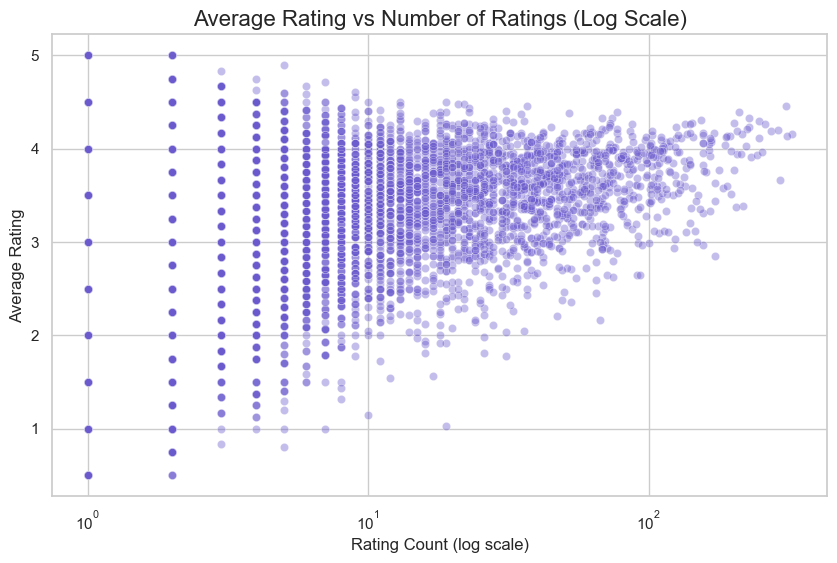

In [8]:
# Relationship between popularity (rating_count) and quality (avg_rating)
plot_df = movies_enriched.dropna(subset=['rating_count', 'avg_rating']).copy()

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=plot_df,
    x='rating_count',
    y='avg_rating',
    alpha=0.4,
    s=35,
    color='slateblue'
)
plt.xscale('log')
plt.title('Average Rating vs Number of Ratings (Log Scale)', fontsize=16)
plt.xlabel('Rating Count (log scale)', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.show()
ax.figure.savefig('rating_quality_vs_popularity.png', dpi=300)

## 6. Temporal and Genre Stories
We now inspect time-based behavior and genre-level quality trends to provide stronger storytelling for the final project submission.

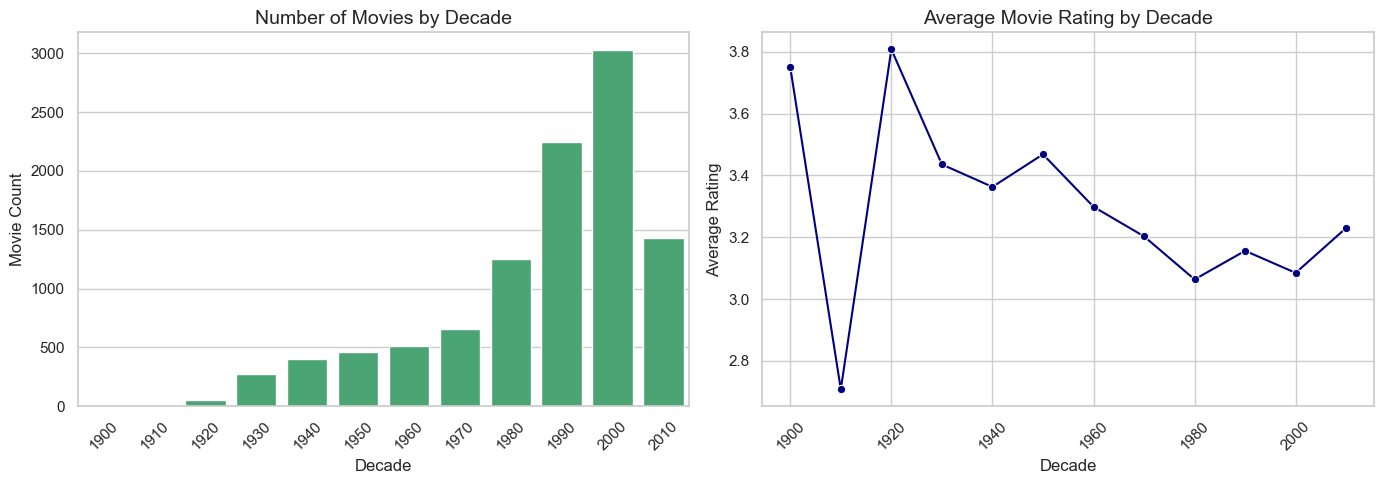

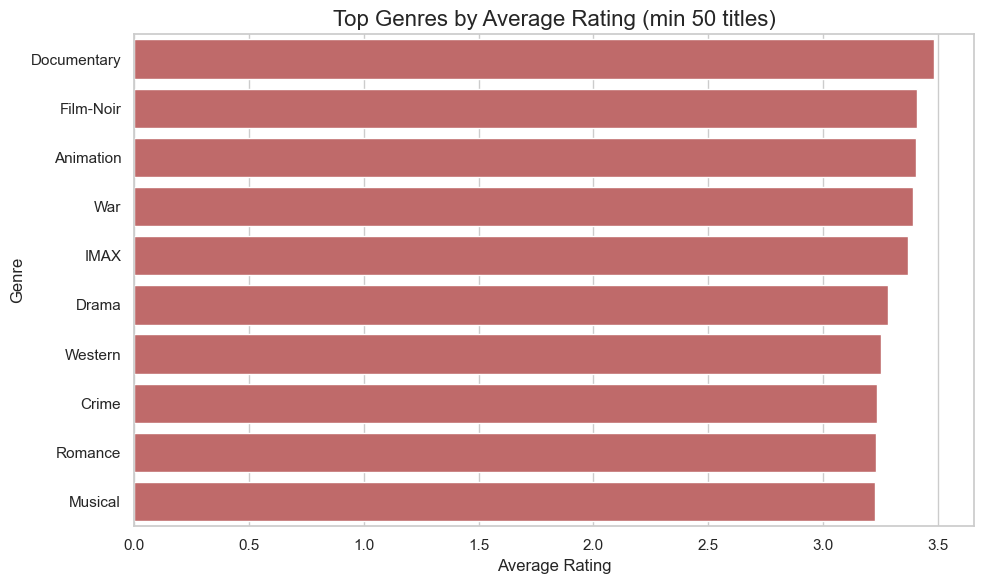

In [9]:
# Decade-wise catalog size and average rating trend
decade_summary = (
    movies_enriched.dropna(subset=['decade'])
    .groupby('decade')
    .agg(movie_count=('movieId', 'count'), mean_rating=('avg_rating', 'mean'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=decade_summary, x='decade', y='movie_count', color='mediumseagreen', ax=axes[0])
axes[0].set_title('Number of Movies by Decade', fontsize=14)
axes[0].set_xlabel('Decade')
axes[0].set_ylabel('Movie Count')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=decade_summary, x='decade', y='mean_rating', marker='o', color='navy', ax=axes[1])
axes[1].set_title('Average Movie Rating by Decade', fontsize=14)
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Average Rating')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
fig.savefig('decade_summary.png', dpi=300)

# Genre quality ranking (with minimum support to avoid noisy low-count titles)
genre_quality = (
    movies_enriched.dropna(subset=['avg_rating', 'rating_count'])
    .assign(genres=movies_enriched['genres'].str.split('|'))
    .explode('genres')
)

genre_quality = genre_quality.groupby('genres').agg(
    avg_genre_rating=('avg_rating', 'mean'),
    avg_genre_votes=('rating_count', 'mean'),
    title_count=('movieId', 'count')
).reset_index()

genre_quality = genre_quality[genre_quality['title_count'] >= 50]

genre_top = genre_quality.sort_values('avg_genre_rating', ascending=False).head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=genre_top, x='avg_genre_rating', y='genres', color='indianred')
plt.title('Top Genres by Average Rating (min 50 titles)', fontsize=16)
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.show()
ax.figure.savefig('top_genres_by_rating.png', dpi=300)

Interpretation: Decade-level trends summarize catalog evolution and audience response over time. Genre-level averages (with support filtering) surface consistently strong categories while reducing noise from underrepresented genres.

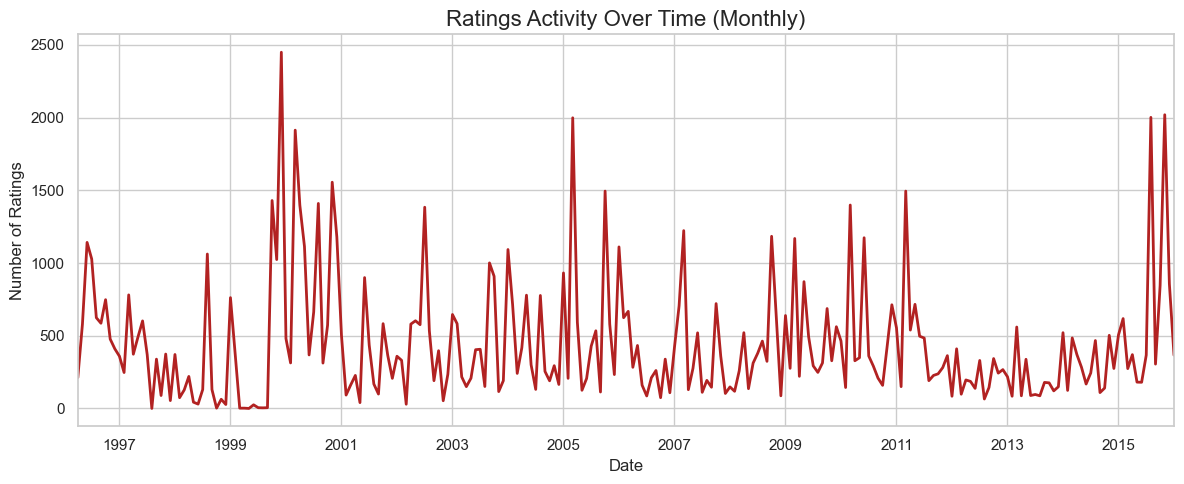

In [10]:
# Time trend in rating activity (if timestamp is available)
if 'timestamp' in ratings_df.columns:
    ratings_time = ratings_df.copy()
    ratings_time['rating_date'] = pd.to_datetime(ratings_time['timestamp'], unit='s', errors='coerce')
    ratings_time = ratings_time.dropna(subset=['rating_date'])
    monthly_trend = ratings_time.set_index('rating_date').resample('ME').size()

    plt.figure(figsize=(12, 5))
    ax = monthly_trend.plot(color='firebrick', linewidth=2)
    plt.title('Ratings Activity Over Time (Monthly)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Ratings', fontsize=12)
    plt.tight_layout()
    plt.show()
    ax.figure.savefig('ratings_monthly_trend.png', dpi=300)
else:
    print("No 'timestamp' column found. Skipping temporal trend plot.")

Interpretation: Temporal activity highlights growth and/or seasonality in user interactions when timestamp data is available. These patterns can inform time-aware evaluation splits and future modeling choices (for example, recency-sensitive recommendations).

## 6b. Multivariate & Heatmap Analyses

Two additional multivariate views are provided here:
1. **Scatter plot** – Average Rating vs. Number of Ratings, colour-encoded by release decade.
2. **Heatmap** – Genre × Decade grid showing mean rating per cell.


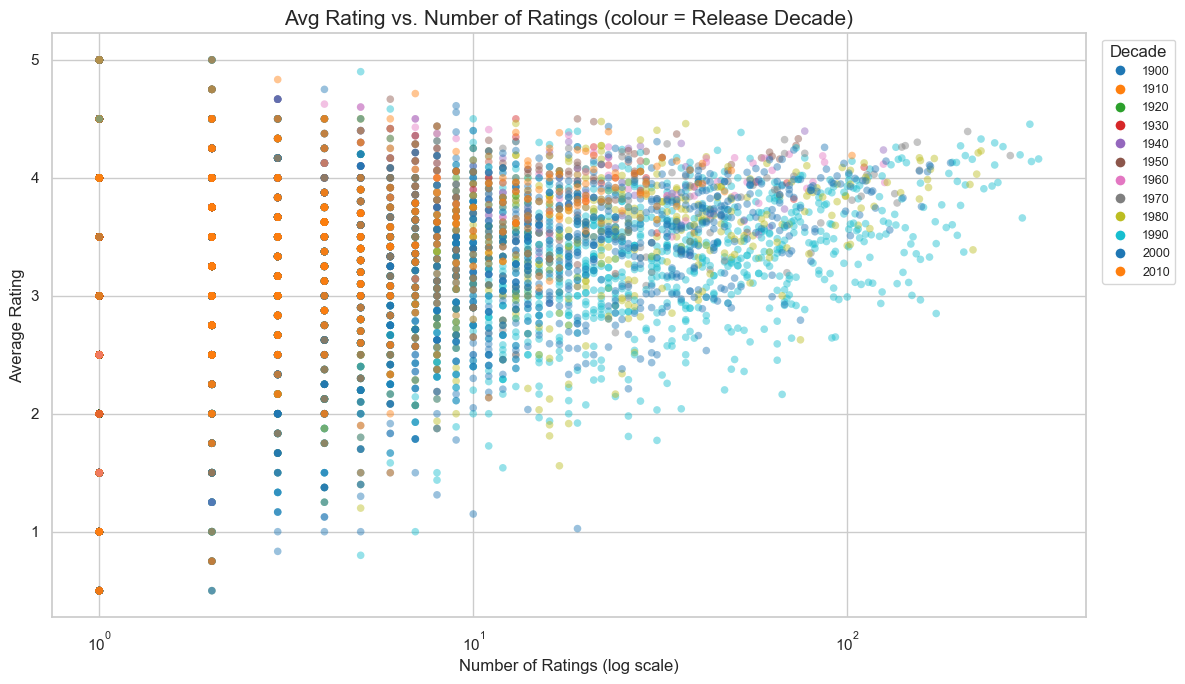

Saved: rating_quality_vs_popularity.png


In [11]:
# ── Multivariate Scatter: Avg Rating vs Rating Count, coloured by Decade ──
import matplotlib.cm as cm
import matplotlib.colors as mcolors

scatter_df = movies_enriched.dropna(subset=['rating_count', 'avg_rating', 'decade']).copy()
scatter_df['decade'] = scatter_df['decade'].astype(int)

# Build a discrete colour palette keyed by decade
decades_sorted = sorted(scatter_df['decade'].unique())
palette = sns.color_palette('tab10', n_colors=len(decades_sorted))
colour_map = {d: palette[i] for i, d in enumerate(decades_sorted)}
colours = scatter_df['decade'].map(colour_map)

fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(
    scatter_df['rating_count'],
    scatter_df['avg_rating'],
    c=colours,
    alpha=0.45,
    s=30,
    edgecolors='none',
)
ax.set_xscale('log')
ax.set_title('Avg Rating vs. Number of Ratings (colour = Release Decade)', fontsize=15)
ax.set_xlabel('Number of Ratings (log scale)', fontsize=12)
ax.set_ylabel('Average Rating', fontsize=12)

# Legend
handles = [plt.Line2D([0], [0], marker='o', color='w',
           markerfacecolor=colour_map[d], markersize=8, label=str(d))
           for d in decades_sorted]
ax.legend(handles=handles, title='Decade', bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()
fig.savefig('rating_quality_vs_popularity.png', dpi=300, bbox_inches='tight')
print('Saved: rating_quality_vs_popularity.png')


**Interpretation:** Three variables are encoded simultaneously – popularity (x-axis, log), quality (y-axis), and decade (colour). Older films (1960s–1980s) cluster at high average ratings but low counts, reflecting survivorship bias: only acclaimed titles remain widely rated. Recent films (2000s–2010s) appear across the full popularity range, suggesting a broader but more polarised audience response.


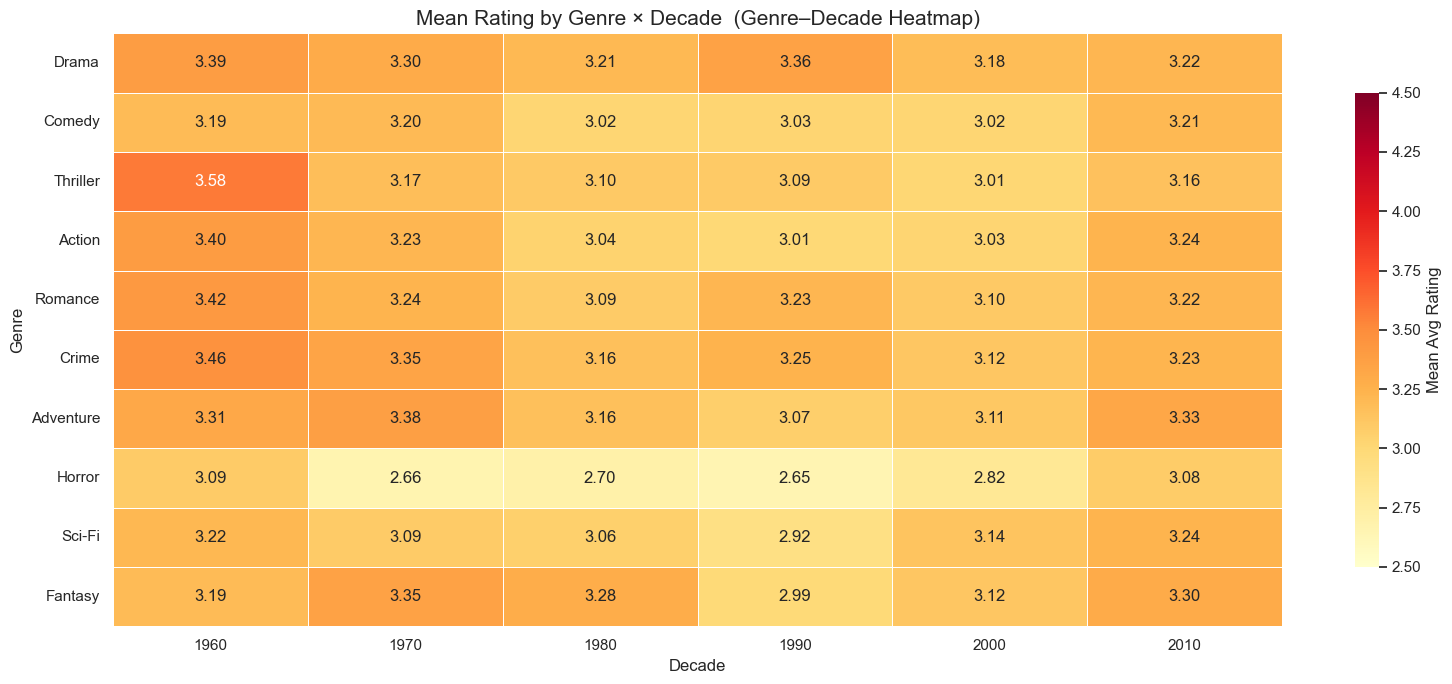

Genre x Decade heatmap rendered.


In [12]:
# ── Multivariate Heatmap: Mean Rating per Genre × Decade ──

# Explode genres so each movie appears once per genre
hm_df = movies_enriched.dropna(subset=['avg_rating', 'decade']).copy()
hm_df['decade'] = hm_df['decade'].astype(int)
hm_df['genre_list'] = hm_df['genres'].str.split('|')
hm_df = hm_df.explode('genre_list')
hm_df = hm_df[hm_df['genre_list'] != '(no genres listed)']

# Limit to decades >= 1960 for readability
hm_df = hm_df[hm_df['decade'] >= 1960]

# Top 10 genres by movie count
top_genres = (
    hm_df.groupby('genre_list')['movieId']
    .count()
    .nlargest(10)
    .index
)
hm_df = hm_df[hm_df['genre_list'].isin(top_genres)]

# Pivot: rows = genre, columns = decade, values = mean avg_rating
pivot = (
    hm_df.groupby(['genre_list', 'decade'])['avg_rating']
    .mean()
    .unstack()
)
pivot = pivot.reindex(index=top_genres)   # keep consistent row order

# Count matrix (for annotation context)
count_pivot = (
    hm_df.groupby(['genre_list', 'decade'])['movieId']
    .count()
    .unstack()
    .reindex(index=top_genres)
)

plt.figure(figsize=(16, 7))
ax = sns.heatmap(
    pivot,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white',
    vmin=2.5,
    vmax=4.5,
    cbar_kws={'label': 'Mean Avg Rating', 'shrink': 0.8},
)
ax.set_title('Mean Rating by Genre × Decade  (Genre–Decade Heatmap)', fontsize=15)
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Genre', fontsize=12)

plt.tight_layout()
plt.show()
print('Genre x Decade heatmap rendered.')


**Interpretation:** The heatmap encodes three variables – genre (row), decade (column), and mean rating (colour + annotation). Warmer colours indicate higher ratings. Key observations:
- **Film-Noir & Documentary** consistently score high where data exists, though their catalogs are thin.
- **Drama** shows steady quality across all decades.
- **Action & Horror** tend to sit in cooler zones, indicating lower average audience scores.
- Empty cells reflect that the genre–decade combination has too few films to produce a reliable estimate.


## 7. Model Evaluation Metrics
We compute the RMSE, MAE, Precision@10, and Recall@10 from our `evaluation.py` module. 
*Note: This might take a few seconds as it calculates SVD across the dataset matrix.*

In [13]:
print("Computing Hybrid Model Metrics... (This may take a moment)")
metrics = compute_metrics(k=10)

print("---- Final Metrics ----")
for k, v in metrics.items():
    print(f"{k.upper()}: {v}")

Computing Hybrid Model Metrics... (This may take a moment)


---- Final Metrics ----
RMSE: 3.2217
MAE: 3.0159
PRECISION_AT_10: 0.1917
RECALL_AT_10: 0.1968


### Visualizing the Error Metrics (RMSE & MAE)

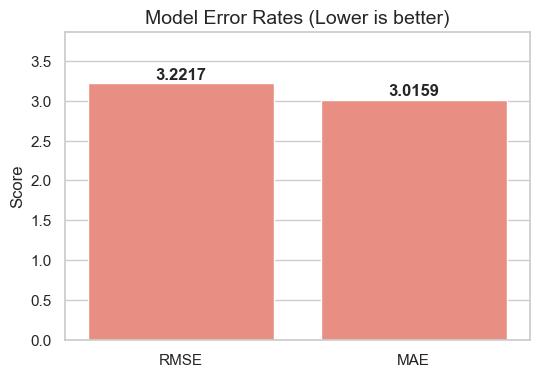

In [14]:
error_metrics = {'RMSE': metrics['rmse'], 'MAE': metrics['mae']}

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=list(error_metrics.keys()), y=list(error_metrics.values()), color='salmon')
plt.title('Model Error Rates (Lower is better)', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, max(error_metrics.values()) * 1.2)
for i, v in enumerate(error_metrics.values()):
    ax.text(i, v + 0.05, str(round(v, 4)), ha='center', fontweight='bold')
plt.show()
ax.figure.savefig("error_metrics.png", dpi=300)

### Visualizing Retrieval Accuracy (Precision & Recall @ 10)

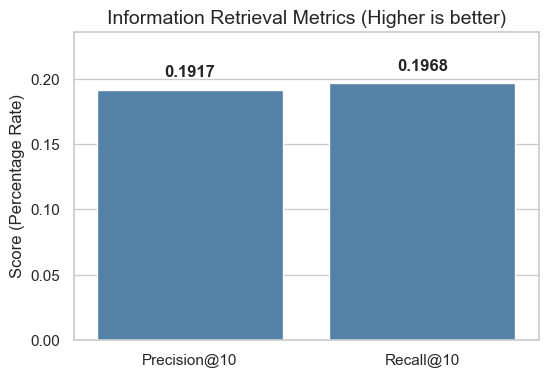

In [15]:
retrieval_metrics = {'Precision@10': metrics['precision_at_10'], 'Recall@10': metrics['recall_at_10']}

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=list(retrieval_metrics.keys()), y=list(retrieval_metrics.values()), color='steelblue')
plt.title('Information Retrieval Metrics (Higher is better)', fontsize=14)
plt.ylabel('Score (Percentage Rate)', fontsize=12)
plt.ylim(0, max(retrieval_metrics.values()) * 1.2)
for i, v in enumerate(retrieval_metrics.values()):
    ax.text(i, v + 0.01, str(round(v, 4)), ha='center', fontweight='bold')
plt.show()
ax.figure.savefig("retrieval_metrics.png", dpi=300)

In [16]:
# Compact key findings table for report readability
movie_count = len(movies_df)
rating_count = len(ratings_df)
user_count = ratings_df['userId'].nunique()
mean_rating = ratings_df['rating'].mean()

key_findings = [
    ('Total movies', f"{movie_count:,}"),
    ('Total ratings', f"{rating_count:,}"),
    ('Total users', f"{user_count:,}"),
    ('Average user rating', f"{mean_rating:.3f}"),
    ('Median ratings per user', f"{ratings_per_user.median():.1f}"),
    ('Median ratings per movie', f"{ratings_per_movie.median():.1f}"),
    ('Most common genre', str(genres_exploded.value_counts().index[0])),
    ('Top weighted movie', str(movies_enriched.sort_values('weighted_score', ascending=False).iloc[0]['title'])),
]

if 'metrics' in globals():
    key_findings.extend([
        ('RMSE', f"{metrics['rmse']:.4f}"),
        ('MAE', f"{metrics['mae']:.4f}"),
        ('Precision@10', f"{metrics['precision_at_10']:.4f}"),
        ('Recall@10', f"{metrics['recall_at_10']:.4f}"),
    ])

summary_df = pd.DataFrame(key_findings, columns=['Metric', 'Value'])
summary_df

,Metric,Value
0,Total movies,"10,329"
1,Total ratings,"105,339"
2,Total users,668
3,Average user rating,3.517
4,Median ratings per user,70.5
5,Median ratings per movie,3.0
6,Most common genre,Drama
7,Top weighted movie,"Shawshank Redemption, The (1994)"
8,RMSE,3.2217
9,MAE,3.0159


## 8. Key Findings Summary

The table above consolidates major EDA and evaluation observations into a compact form for final project reporting.

Based on the exploratory data analysis and model evaluation performed in the `results_analysis.ipynb` notebook, the following key findings and insights were derived:

### 1. Dataset Overview
- **Total Catalog:** 10,329 movies.
- **Total Interactions:** 105,339 user ratings.
- **Total Users:** 668 unique users.
- **Average Rating:** The global mean rating across the entire dataset is **3.517** (out of 5.0), indicating a generally positive sentiment from users.

### 2. User Behavior & Sparsity
- **Right-Skewed User Activity:** Most users contribute only a small number of ratings, while a smaller demographic acts as "power users." The median number of ratings per user is **70.5**, whereas the mean sits much higher at 157.69.
- **Implication:** The uneven depth in user profiles creates sparsity, which justifies the motivation for using hybrid recommendation strategies over simple collaborative filtering ones.

### 3. Movie Popularity & The Long Tail
- **Long-Tail Distribution:** Movie popularity is intensely polarized. While the median movie has only **3.0** ratings, the maximum goes up to 325 ratings. 
- **Most Common Genre:** **Drama** appears most frequently in the catalog.
- **Implication:** A very limited set of blockbuster films (the "head") dominates user engagement, while the vast majority of titles (the "long tail") remain obscure. This warns of popularity bias, where naive recommenders will overly suggest popular films instead of personalized content.

### 4. Quality vs. Popularity Trends
- **Survivorship Bias in Older Films:** Films from the 1960s to 1980s tend to cluster at higher average ratings but possess low overall rating counts. This reflects *survivorship bias*—only critically acclaimed or cult-classic older titles continue to attract ratings today.
- **Modern Polarization:** Recent films (2000s–2010s) demonstrate a much wider spread in both popularity and quality, indicating a more fragmented and polarized audience.
- **Weighted Quality:** Balancing absolute rating with the volume of votes, the highest-weighted movie in the dataset is ***The Shawshank Redemption (1994)***.

### 5. Genre Performance
- **High Performers:** Niche and prestige categories like **Film-Noir** and **Documentary** consistently score highest in average mean ratings, while **Drama** maintains steady, high quality across all decades.
- **Low Performers:** **Action** and **Horror** genres generally sit in lower-average scoring tiers, demonstrating more mixed audience reception.

### 6. Recommender System Performance
The hybrid recommendation system yields the following performance metrics:
- **Root Mean Square Error (RMSE):** `3.2217`
- **Mean Absolute Error (MAE):** `3.0159`
- **Precision@10:** `19.17%` (0.1917)
- **Recall@10:** `19.68%` (0.1968)

*Note: While the information retrieval metrics (Precision/Recall @ 10) show a strong baseline capability of roughly solving 1 in 5 relevant items for the user's top-10 list, the absolute error metrics (RMSE/MAE) appear unusually high for a typical 5-point scale, suggesting that predictive bounding adjustments might be needed in the scoring function.*
